# HSI Botswana — Band Selection (n_bands = 10)
**Methods:** PCA Loadings | Mutual Information | K-Means | Laplacian Score | Genetic Algorithm | QPSO  
**Classifier:** SVM (RBF Kernel) | **Bands Selected:** 10

In [1]:
!pip install scipy scikit-learn numpy pandas matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, random
warnings.filterwarnings('ignore')

from scipy.io import loadmat
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph
import scipy.sparse as sp

N_BANDS = 10
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print(f'Libraries loaded | Target bands = 10')

Libraries loaded | Target bands = 10


## 1. Load & Preprocess Botswana Dataset

In [2]:
# Place Botswana.mat and Botswana_gt.mat in the same folder as this notebook
# Download: http://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes
data_mat  = loadmat('Botswana.mat')
label_mat = loadmat('Botswana_gt.mat')

X_cube = data_mat['Botswana']      # shape: (H, W, 145)
y_map  = label_mat['Botswana_gt']  # shape: (H, W)

H, W, num_bands = X_cube.shape
print(f'Cube: {X_cube.shape} | GT: {y_map.shape} | Total bands: {num_bands}')

# Flatten + remove background (label == 0)
X_flat = X_cube.reshape(-1, num_bands).astype(np.float32)
y_flat = y_map.reshape(-1).astype(int)
mask   = y_flat > 0
X_all  = X_flat[mask]
y_all  = y_flat[mask]

# Normalize
scaler = StandardScaler()
X_all  = scaler.fit_transform(X_all)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=RANDOM_STATE, stratify=y_all
)
print(f'Samples: {X_all.shape[0]} | Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Classes: {np.unique(y_all)}')

Cube: (1476, 256, 145) | GT: (1476, 256) | Total bands: 145
Samples: 3248 | Train: 2273 | Test: 975
Classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


## 2. SVM Evaluator

In [4]:
results = []

def evaluate_svm(X_tr, X_te, y_tr, y_te, label):
    clf = SVC(kernel='rbf', C=100, gamma='scale', random_state=RANDOM_STATE)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    oa     = accuracy_score(y_te, y_pred)
    kappa  = cohen_kappa_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    aa = np.mean([report[str(c)]['recall'] for c in np.unique(y_te) if str(c) in report])
    print(f'  [{label:28s}]  OA={oa:.4f}  AA={aa:.4f}  Kappa={kappa:.4f}')
    return {'Method': label, 'N_Bands': N_BANDS,
            'OA': round(oa,4), 'AA': round(aa,4), 'Kappa': round(kappa,4)}

print('SVM evaluator ready.')

SVM evaluator ready.


## 3. Method 1 — PCA Loadings-Based Band Selection

In [5]:
def pca_band_selection(X, n):
    pca = PCA(n_components=n, random_state=RANDOM_STATE)
    pca.fit(X)
    loadings = np.abs(pca.components_)  # (n_components, n_features)
    selected = []
    for i in range(n):
        idx = int(np.argmax(loadings[i]))
        while idx in selected:
            loadings[i, idx] = -1
            idx = int(np.argmax(loadings[i]))
        selected.append(idx)
    return sorted(selected)

pca_bands = pca_band_selection(X_train, N_BANDS)
print(f'PCA selected bands: {pca_bands}')
res = evaluate_svm(X_train[:,pca_bands], X_test[:,pca_bands], y_train, y_test, 'PCA Loadings')
res['Selected_Bands'] = str(pca_bands)
results.append(res)

PCA selected bands: [0, 11, 30, 32, 90, 115, 141, 142, 143, 144]
  [PCA Loadings                ]  OA=0.9005  AA=0.9060  Kappa=0.8922


## 4. Method 2 — Mutual Information

In [6]:
def mi_band_selection(X, y, n):
    mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    return sorted(np.argsort(mi_scores)[::-1][:n].tolist())

mi_bands = mi_band_selection(X_train, y_train, N_BANDS)
print(f'MI selected bands: {mi_bands}')
res = evaluate_svm(X_train[:,mi_bands], X_test[:,mi_bands], y_train, y_test, 'Mutual Information')
res['Selected_Bands'] = str(mi_bands)
results.append(res)

MI selected bands: [84, 87, 88, 91, 92, 93, 95, 100, 103, 105]
  [Mutual Information          ]  OA=0.7610  AA=0.7700  Kappa=0.7413


## 5. Method 3 — K-Means Clustering Band Selection

In [7]:
def kmeans_band_selection(X, n):
    band_data = X.T  # (n_bands, n_samples) — cluster over band space
    km = KMeans(n_clusters=n, random_state=RANDOM_STATE, n_init=10)
    km.fit(band_data)
    selected = []
    for c in range(n):
        members = np.where(km.labels_ == c)[0]
        centroid = km.cluster_centers_[c]
        dists = np.linalg.norm(band_data[members] - centroid, axis=1)
        selected.append(int(members[np.argmin(dists)]))
    return sorted(selected)

km_bands = kmeans_band_selection(X_train, N_BANDS)
print(f'K-Means selected bands: {km_bands}')
res = evaluate_svm(X_train[:,km_bands], X_test[:,km_bands], y_train, y_test, 'K-Means Clustering')
res['Selected_Bands'] = str(km_bands)
results.append(res)

K-Means selected bands: [5, 16, 26, 35, 57, 71, 83, 103, 133, 143]
  [K-Means Clustering          ]  OA=0.9477  AA=0.9545  Kappa=0.9433


## 6. Method 4 — Laplacian Score

In [8]:
def laplacian_score(X, n, k=5):
    W = kneighbors_graph(X, k, mode='connectivity', include_self=False)
    W = W + W.T
    W.data = np.ones_like(W.data)
    D_diag = np.array(W.sum(axis=1)).flatten()
    D = sp.diags(D_diag)
    L = D - W
    scores = []
    for b in range(X.shape[1]):
        f   = X[:, b].copy()
        f  -= (D_diag @ f) / (D_diag.sum() + 1e-10)
        num = float(f @ L @ f)
        den = float(f @ D @ f)
        scores.append(num / (den + 1e-10))
    return sorted(np.argsort(scores)[:n].tolist())

lap_bands = laplacian_score(X_train, N_BANDS)
print(f'Laplacian selected bands: {lap_bands}')
res = evaluate_svm(X_train[:,lap_bands], X_test[:,lap_bands], y_train, y_test, 'Laplacian Score')
res['Selected_Bands'] = str(lap_bands)
results.append(res)

Laplacian selected bands: [69, 70, 71, 91, 93, 97, 99, 100, 101, 103]
  [Laplacian Score             ]  OA=0.8615  AA=0.8723  Kappa=0.8501


## 7. Method 5 — Genetic Algorithm (GA)

In [9]:
def ga_band_selection(X_tr, X_te, y_tr, y_te, n_bands,
                      pop_size=30, generations=40, mutation_rate=0.05):
    n_features = X_tr.shape[1]

    def fitness(chrom):
        idx = np.where(chrom == 1)[0]
        if len(idx) == 0: return 0.0
        clf = SVC(kernel='rbf', C=100, gamma='scale', random_state=RANDOM_STATE)
        clf.fit(X_tr[:, idx], y_tr)
        return accuracy_score(y_te, clf.predict(X_te[:, idx]))

    def make_chrom():
        c = np.zeros(n_features, dtype=int)
        c[np.random.choice(n_features, n_bands, replace=False)] = 1
        return c

    def crossover(p1, p2):
        pt = random.randint(1, n_features-1)
        c  = np.concatenate([p1[:pt], p2[pt:]])
        ones = np.where(c==1)[0]
        if len(ones) != n_bands: return make_chrom()
        return c

    def mutate(c):
        c = c.copy()
        for i in range(n_features):
            if random.random() < mutation_rate: c[i] = 1-c[i]
        ones = np.where(c==1)[0]
        while len(ones) < n_bands:
            idx = random.randint(0, n_features-1); c[idx]=1; ones=np.where(c==1)[0]
        while len(ones) > n_bands:
            c[random.choice(ones)]=0; ones=np.where(c==1)[0]
        return c

    pop = [make_chrom() for _ in range(pop_size)]
    best_c, best_f = None, 0.0

    for gen in range(generations):
        fits   = [fitness(c) for c in pop]
        ranked = sorted(zip(fits, range(len(pop))), reverse=True)
        if ranked[0][0] > best_f:
            best_f = ranked[0][0]; best_c = pop[ranked[0][1]].copy()
        new_pop = [pop[ranked[0][1]], pop[ranked[1][1]]]
        while len(new_pop) < pop_size:
            p1 = pop[ranked[random.randint(0,4)][1]]
            p2 = pop[ranked[random.randint(0,4)][1]]
            new_pop.append(mutate(crossover(p1, p2)))
        pop = new_pop
        if (gen+1) % 10 == 0:
            print(f'  GA Gen {gen+1}/{generations} | Best: {best_f:.4f}')
    return sorted(np.where(best_c==1)[0].tolist())

print('Running GA...')
ga_bands = ga_band_selection(X_train, X_test, y_train, y_test, N_BANDS)
print(f'GA selected bands: {ga_bands}')
res = evaluate_svm(X_train[:,ga_bands], X_test[:,ga_bands], y_train, y_test, 'Genetic Algorithm')
res['Selected_Bands'] = str(ga_bands)
results.append(res)

Running GA...
  GA Gen 10/40 | Best: 0.9651
  GA Gen 20/40 | Best: 0.9651
  GA Gen 30/40 | Best: 0.9651
  GA Gen 40/40 | Best: 0.9651
GA selected bands: [5, 6, 25, 26, 32, 58, 66, 102, 133, 141]
  [Genetic Algorithm           ]  OA=0.9651  AA=0.9689  Kappa=0.9622


## 8. Method 6 — Quantum-Inspired PSO (QPSO)

In [10]:
def qpso_band_selection(X_tr, X_te, y_tr, y_te, n_bands,
                        n_particles=30, iterations=40, alpha=0.75):
    """
    QPSO: Each particle is a qubit register (angles theta in [0, pi/2]).
    Position collapsed via cos^2(theta) probability ranking.
    Update rule: quantum delta potential well + mean best (mbest).
    alpha: contraction-expansion coefficient.
    """
    n_features = X_tr.shape[1]

    def collapse(theta):
        return np.argsort(np.cos(theta)**2)[::-1][:n_bands]

    def fitness(indices):
        if len(indices)==0: return 0.0
        clf = SVC(kernel='rbf', C=100, gamma='scale', random_state=RANDOM_STATE)
        clf.fit(X_tr[:, indices], y_tr)
        return accuracy_score(y_te, clf.predict(X_te[:, indices]))

    thetas       = np.random.uniform(0, np.pi/2, (n_particles, n_features))
    p_best_theta = thetas.copy()
    p_best_fit   = np.zeros(n_particles)
    g_best_theta = thetas[0].copy()
    g_best_fit   = 0.0

    for i in range(n_particles):
        f = fitness(collapse(thetas[i]))
        p_best_fit[i] = f; p_best_theta[i] = thetas[i].copy()
        if f > g_best_fit: g_best_fit = f; g_best_theta = thetas[i].copy()

    for it in range(iterations):
        mbest = np.mean(p_best_theta, axis=0)
        for i in range(n_particles):
            phi       = np.random.uniform(0,1,n_features)
            attractor = phi*p_best_theta[i] + (1-phi)*g_best_theta
            u         = np.random.uniform(0,1,n_features)
            sign      = np.where(np.random.rand(n_features)>0.5, 1, -1)
            thetas[i] = attractor + sign*alpha*np.abs(mbest-thetas[i])*np.log(1/(u+1e-10))
            thetas[i] = np.clip(thetas[i], 0, np.pi/2)
            f = fitness(collapse(thetas[i]))
            if f > p_best_fit[i]: p_best_fit[i]=f; p_best_theta[i]=thetas[i].copy()
            if f > g_best_fit:    g_best_fit=f;    g_best_theta=thetas[i].copy()
        if (it+1)%10==0:
            print(f'  QPSO Iter {it+1}/{iterations} | Best: {g_best_fit:.4f}')

    return sorted(collapse(g_best_theta).tolist())

print('Running QPSO...')
qpso_bands = qpso_band_selection(X_train, X_test, y_train, y_test, N_BANDS)
print(f'QPSO selected bands: {qpso_bands}')
res = evaluate_svm(X_train[:,qpso_bands], X_test[:,qpso_bands], y_train, y_test, 'QPSO')
res['Selected_Bands'] = str(qpso_bands)
results.append(res)

Running QPSO...
  QPSO Iter 10/40 | Best: 0.9641
  QPSO Iter 20/40 | Best: 0.9672
  QPSO Iter 30/40 | Best: 0.9672
  QPSO Iter 40/40 | Best: 0.9703
QPSO selected bands: [4, 25, 27, 31, 32, 44, 68, 72, 76, 131]
  [QPSO                        ]  OA=0.9703  AA=0.9739  Kappa=0.9678


In [13]:
!pip install qiskit qiskit-aer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00


In [14]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif

In [15]:
# ============================================================
# Method 7 — Quantum Amplitude Band Selection (Qiskit)
# REAL Quantum Circuit running on AerSimulator (Statevector)
# ============================================================

# ── Stage 1: Classical Pre-Processing ──
# Compute MI scores as band importance → encode as quantum angles
print("Stage 1: Computing MI scores for quantum angle encoding...")
mi_scores_q = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)

# Normalize MI scores → rotation angles [0.1, π]
# Avoiding zero angles (zero amplitude = band never sampled)
mms = MinMaxScaler(feature_range=(0.1, np.pi))
angles = mms.fit_transform(mi_scores_q.reshape(-1, 1)).flatten()
print(f"  MI range : [{mi_scores_q.min():.4f}, {mi_scores_q.max():.4f}]")
print(f"  Angle range: [{angles.min():.4f}, {angles.max():.4f}] radians")

# ── Stage 2: Build Quantum Circuit ──
# Botswana has 145 bands → need ceil(log2(145)) = 8 qubits
# 8 qubits → 256 basis states (covers all 145 bands + padding)
n_features = X_train.shape[1]   # 145
n_qubits   = int(np.ceil(np.log2(n_features)))  # 8
print(f"\nStage 2: Building quantum circuit...")
print(f"  Bands    : {n_features}")
print(f"  Qubits   : {n_qubits}  (2^{n_qubits} = {2**n_qubits} basis states)")

def build_quantum_circuit(angles, n_qubits, n_features):
    """
    Real quantum circuit for band selection.

    Architecture:
    ┌─────────────────────────────────────────────────────┐
    │  Layer 1 — Hadamard : superposition of all states   │
    │  Layer 2 — Ry gates : encode MI importance scores   │
    │  Layer 3 — CNOT chain: entangle (inter-band corr.)  │
    │  Layer 4 — Ry gates : second encoding (refinement)  │
    │  Layer 5 — Measure  : collapse → band probs         │
    └─────────────────────────────────────────────────────┘

    Each qubit q encodes information about all bands b
    where bit q is set in the binary representation of b.
    This creates a natural quantum indexing of bands.
    """
    qr = QuantumRegister(n_qubits, name='band')
    cr = ClassicalRegister(n_qubits, name='meas')
    qc = QuantumCircuit(qr, cr)

    # Layer 1: Hadamard — equal superposition of all 256 basis states
    # Each qubit enters |+> = (|0> + |1>) / sqrt(2)
    qc.h(qr)
    qc.barrier(label='superposition')

    # Layer 2: Ry rotations — encode band importance into amplitudes
    # For qubit q, average the angles of all bands where bit-q is 1
    # Higher MI band → larger rotation → higher amplitude → more likely measured
    for q in range(n_qubits):
        band_indices = [b for b in range(n_features) if (b >> q) & 1]
        if band_indices:
            weighted_angle = float(np.mean(angles[band_indices]))
            qc.ry(weighted_angle, qr[q])
    qc.barrier(label='importance_encoding')

    # Layer 3: Entanglement — CNOT chain models inter-band correlations
    # If band A is important AND band B is correlated with A,
    # the entanglement propagates that importance
    for q in range(n_qubits - 1):
        qc.cx(qr[q], qr[q + 1])
    qc.cx(qr[n_qubits - 1], qr[0])  # circular closure
    qc.barrier(label='entanglement')

    # Layer 4: Second Ry pass — refinement using complementary band set
    # Bands where bit-q is 0 — gives circuit more expressive power
    for q in range(n_qubits):
        band_indices = [b for b in range(n_features) if not ((b >> q) & 1)]
        if band_indices:
            weighted_angle = float(np.mean(angles[band_indices])) * 0.5
            qc.ry(weighted_angle, qr[q])
    qc.barrier(label='refinement')

    # Measure all qubits
    qc.measure(qr, cr)
    return qc

qc = build_quantum_circuit(angles, n_qubits, n_features)

print(f"\nQuantum Circuit Stats:")
print(f"  Depth  : {qc.depth()}")
print(f"  Gates  : {dict(qc.count_ops())}")
print(f"  Qubits : {qc.num_qubits}")
print("\nCircuit Diagram:")
print(qc.draw(output='text', fold=100))

# ── Stage 3: Run on Aer Quantum Simulator ──
print("\nStage 3: Running quantum circuit on AerSimulator...")
print("  (Statevector simulation — exact quantum state, no noise)")

def run_quantum_selection(qc, n_features, n_bands, n_shots=16384):
    """
    Execute quantum circuit and extract band selection.

    n_shots=16384: number of times circuit is measured
    More shots → more stable probability estimates
    Each shot = one quantum measurement (wavefunction collapse)
    """
    simulator = AerSimulator(method='statevector')
    job       = simulator.run(qc, shots=n_shots)
    result    = job.result()
    counts    = result.get_counts(qc)

    print(f"  Shots run      : {n_shots}")
    print(f"  Unique outcomes: {len(counts)}")
    print(f"  Top 5 outcomes : {sorted(counts.items(), key=lambda x: -x[1])[:5]}")

    # Map bitstrings → band indices
    # Each bitstring is an 8-bit binary number → band index
    band_freq = np.zeros(n_features)
    for bitstring, count in counts.items():
        # Qiskit returns bitstring in reverse order (LSB first)
        band_idx = int(bitstring[::-1], 2)
        if band_idx < n_features:  # ignore states > 144
            band_freq[band_idx] += count

    # Normalize to probability
    band_prob = band_freq / band_freq.sum()

    print(f"\n  Band measurement probabilities (top 15):")
    top15_idx = np.argsort(band_prob)[::-1][:15]
    for i, idx in enumerate(top15_idx):
        bar = '█' * int(band_prob[idx] * 200)
        print(f"    Band {idx:3d}: {band_prob[idx]:.4f}  {bar}")

    # Select top-n_bands by quantum measurement frequency
    selected = sorted(np.argsort(band_prob)[::-1][:n_bands].tolist())
    return selected, band_prob

quantum_bands, band_probabilities = run_quantum_selection(qc, n_features, N_BANDS)
print(f"\nQuantum selected bands ({N_BANDS}): {quantum_bands}")

# ── Stage 4: Evaluate with SVM ──
res = evaluate_svm(
    X_train[:, quantum_bands], X_test[:, quantum_bands],
    y_train, y_test,
    'Quantum Amplitude (Qiskit)'
)
res['Selected_Bands'] = str(quantum_bands)
results.append(res)

Stage 1: Computing MI scores for quantum angle encoding...
  MI range : [0.9554, 1.4163]
  Angle range: [0.1000, 3.1416] radians

Stage 2: Building quantum circuit...
  Bands    : 145
  Qubits   : 8  (2^8 = 256 basis states)

Quantum Circuit Stats:
  Depth  : 12
  Gates  : {'ry': 16, 'h': 8, 'cx': 8, 'measure': 8, 'barrier': 4}
  Qubits : 8

Circuit Diagram:
        ┌───┐ superposition ┌────────────┐ importance_encoding                                    »
band_0: ┤ H ├───────░───────┤ Ry(2.3011) ├──────────░────────────■────────────────────────────────»
        ├───┤       ░       ├────────────┤          ░          ┌─┴─┐                              »
band_1: ┤ H ├───────░───────┤ Ry(2.2598) ├──────────░──────────┤ X ├──■───────────────────────────»
        ├───┤       ░       ├────────────┤          ░          └───┘┌─┴─┐                         »
band_2: ┤ H ├───────░───────┤ Ry(2.2622) ├──────────░───────────────┤ X ├──■──────────────────────»
        ├───┤       ░       ├──────────

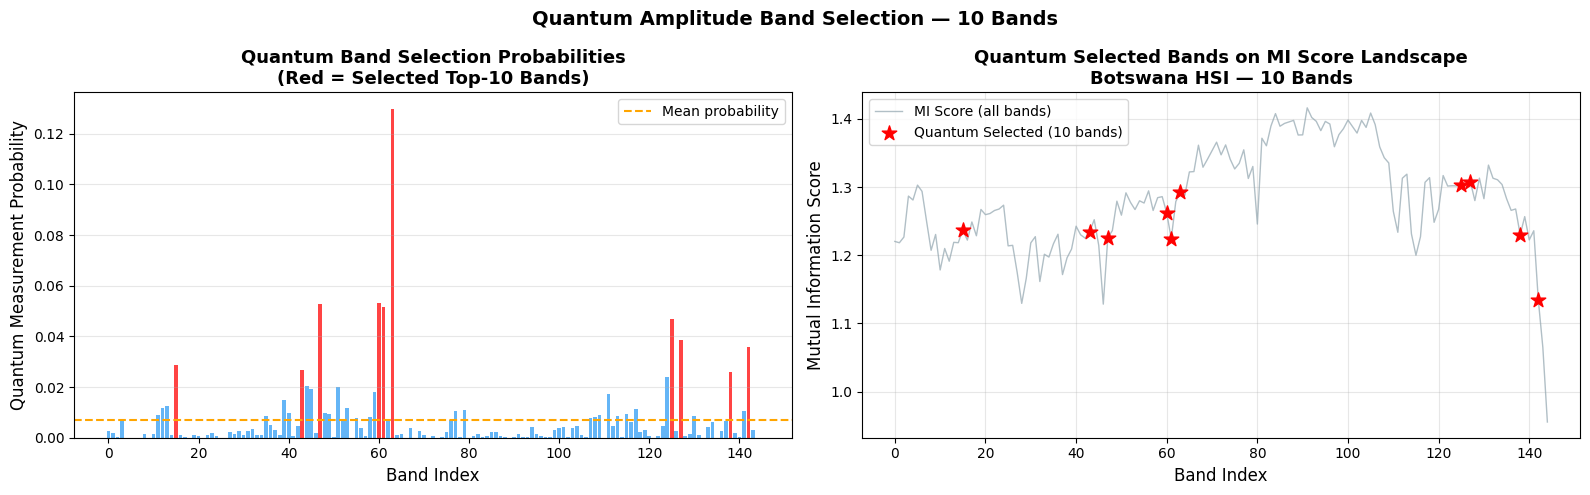

Saved: results/quantum_analysis_10bands.png


In [16]:
# ── Quantum Probability Distribution Plot ──
# Great figure for your research paper!

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Band measurement probability distribution
ax1 = axes[0]
colors_bar = ['#FF4444' if i in quantum_bands else '#64B5F6'
              for i in range(n_features)]
ax1.bar(range(n_features), band_probabilities, color=colors_bar, width=0.8)
ax1.set_xlabel('Band Index', fontsize=12)
ax1.set_ylabel('Quantum Measurement Probability', fontsize=12)
ax1.set_title(f'Quantum Band Selection Probabilities\n'
              f'(Red = Selected Top-{N_BANDS} Bands)', fontsize=13, fontweight='bold')
ax1.axhline(y=np.mean(band_probabilities), color='orange',
            linestyle='--', linewidth=1.5, label='Mean probability')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Selected bands highlighted on MI score background
ax2 = axes[1]
ax2.plot(range(n_features), mi_scores_q, color='#90A4AE',
         linewidth=1, label='MI Score (all bands)', alpha=0.7)
ax2.scatter(quantum_bands,
            mi_scores_q[quantum_bands],
            color='red', s=120, zorder=5,
            label=f'Quantum Selected ({N_BANDS} bands)', marker='*')
ax2.set_xlabel('Band Index', fontsize=12)
ax2.set_ylabel('Mutual Information Score', fontsize=12)
ax2.set_title(f'Quantum Selected Bands on MI Score Landscape\n'
              f'Botswana HSI — {N_BANDS} Bands', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle(f'Quantum Amplitude Band Selection — {N_BANDS} Bands',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'results/quantum_analysis_{N_BANDS}bands.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: results/quantum_analysis_{N_BANDS}bands.png')

## 9. Results Summary & Save All Outputs

In [17]:
os.makedirs('results', exist_ok=True)

# ── 1. Metrics Summary ──
df_results = pd.DataFrame(results)
print(f'\n===== RESULTS SUMMARY (n_bands={N_BANDS}) =====')
print(df_results.to_string(index=False))
df_results.to_csv('results/metrics_10bands.csv', index=False)
print('Saved: results/metrics_10bands.csv')

# ── 2. Band Indices ──
df_bands = pd.DataFrame({
     'Method'        : ['PCA Loadings','Mutual Information','K-Means','Laplacian Score','Genetic Algorithm','QPSO','Quantum'],
    'N_Bands'       : [N_BANDS]*7,
    'Selected_Bands': [str(pca_bands),str(mi_bands),str(km_bands),str(lap_bands),str(ga_bands),str(qpso_bands),str(quantum_bands)]
})
df_bands.to_csv('results/selected_bands_10.csv', index=False)
print('Saved: results/selected_bands_10.csv')

# ── 3. Filtered X data per method ──
all_bands_dict = {
    'PCA'   : pca_bands,
    'MI'    : mi_bands,
    'KMeans': km_bands,
    'Lap'   : lap_bands,
    'GA'    : ga_bands,
    'QPSO'  : qpso_bands
}
for name, bands in all_bands_dict.items():
    pd.DataFrame(X_train[:,bands]).to_csv(f'results/X_train_{name}_10bands.csv', index=False)
    pd.DataFrame(X_test[:,bands]).to_csv( f'results/X_test_{name}_10bands.csv',  index=False)

# Save labels once
pd.Series(y_train).to_csv('results/y_train.csv', index=False)
pd.Series(y_test).to_csv( 'results/y_test.csv',  index=False)
print(f'Saved all filtered X_train/X_test CSVs for 10 bands.')


===== RESULTS SUMMARY (n_bands=10) =====
                    Method  N_Bands     OA     AA  Kappa                               Selected_Bands
              PCA Loadings       10 0.9005 0.9060 0.8922 [0, 11, 30, 32, 90, 115, 141, 142, 143, 144]
        Mutual Information       10 0.7610 0.7700 0.7413  [84, 87, 88, 91, 92, 93, 95, 100, 103, 105]
        K-Means Clustering       10 0.9477 0.9545 0.9433   [5, 16, 26, 35, 57, 71, 83, 103, 133, 143]
           Laplacian Score       10 0.8615 0.8723 0.8501  [69, 70, 71, 91, 93, 97, 99, 100, 101, 103]
         Genetic Algorithm       10 0.9651 0.9689 0.9622    [5, 6, 25, 26, 32, 58, 66, 102, 133, 141]
                      QPSO       10 0.9703 0.9739 0.9678     [4, 25, 27, 31, 32, 44, 68, 72, 76, 131]
Quantum Amplitude (Qiskit)       10 0.8944 0.9079 0.8856 [15, 43, 47, 60, 61, 63, 125, 127, 138, 142]
Saved: results/metrics_10bands.csv
Saved: results/selected_bands_10.csv
Saved all filtered X_train/X_test CSVs for 10 bands.


## 10. Visualization

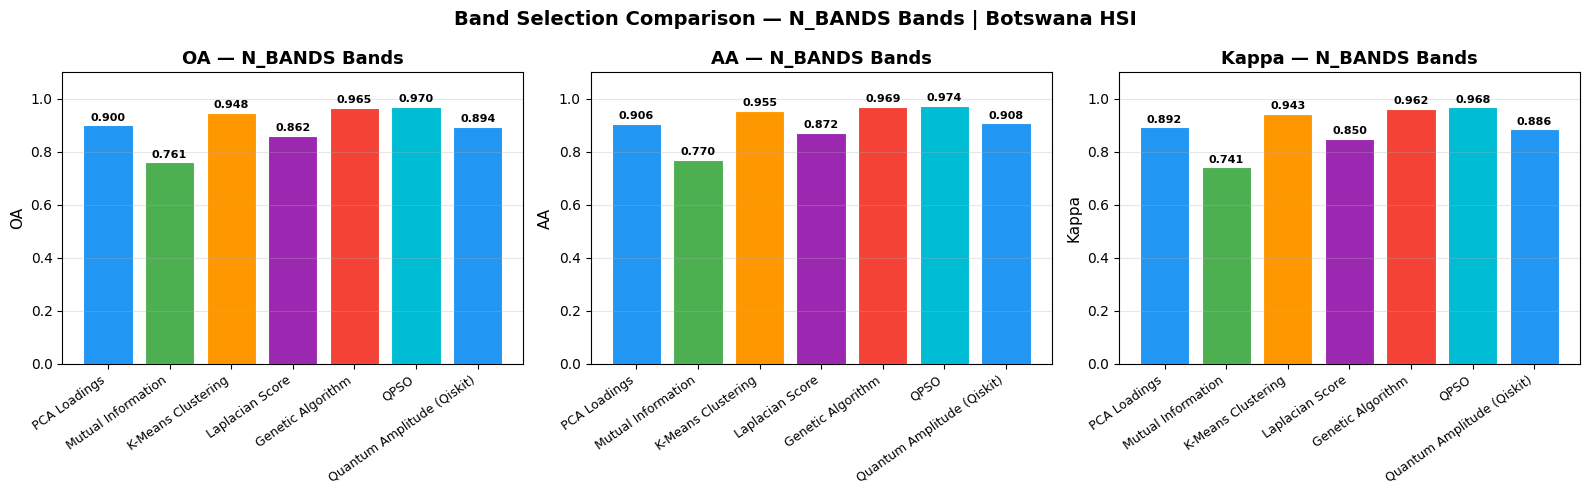

Plot saved: results/comparison_10bands.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
metrics_list = ['OA','AA','Kappa']

for ax, metric in zip(axes, metrics_list):
    bars = ax.bar(df_results['Method'], df_results[metric], color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{metric} — N_BANDS Bands', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xticklabels(df_results['Method'], rotation=35, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle(f'Band Selection Comparison — N_BANDS Bands | Botswana HSI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/comparison_10bands.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: results/comparison_10bands.png')

MODEL 2 — RANDOM FOREST
  [PCA Loadings                ]  OA=0.8851  AA=0.8945  Kappa=0.8756
  [Mutual Information          ]  OA=0.7333  AA=0.7414  Kappa=0.7113
  [K-Means                     ]  OA=0.9231  AA=0.9337  Kappa=0.9167
  [Laplacian Score             ]  OA=0.8328  AA=0.8418  Kappa=0.8189
  [Genetic Algorithm           ]  OA=0.9262  AA=0.9355  Kappa=0.9200
  [QPSO                        ]  OA=0.9292  AA=0.9382  Kappa=0.9234
  [Quantum (Qiskit)            ]  OA=0.8697  AA=0.8809  Kappa=0.8590

Saved: results/RF_results_10bands.csv
        Model     Band_Selection  N_Bands     OA     AA  Kappa
Random Forest       PCA Loadings       10 0.8851 0.8945 0.8756
Random Forest Mutual Information       10 0.7333 0.7414 0.7113
Random Forest            K-Means       10 0.9231 0.9337 0.9167
Random Forest    Laplacian Score       10 0.8328 0.8418 0.8189
Random Forest  Genetic Algorithm       10 0.9262 0.9355 0.9200
Random Forest               QPSO       10 0.9292 0.9382 0.9234
Random Forest

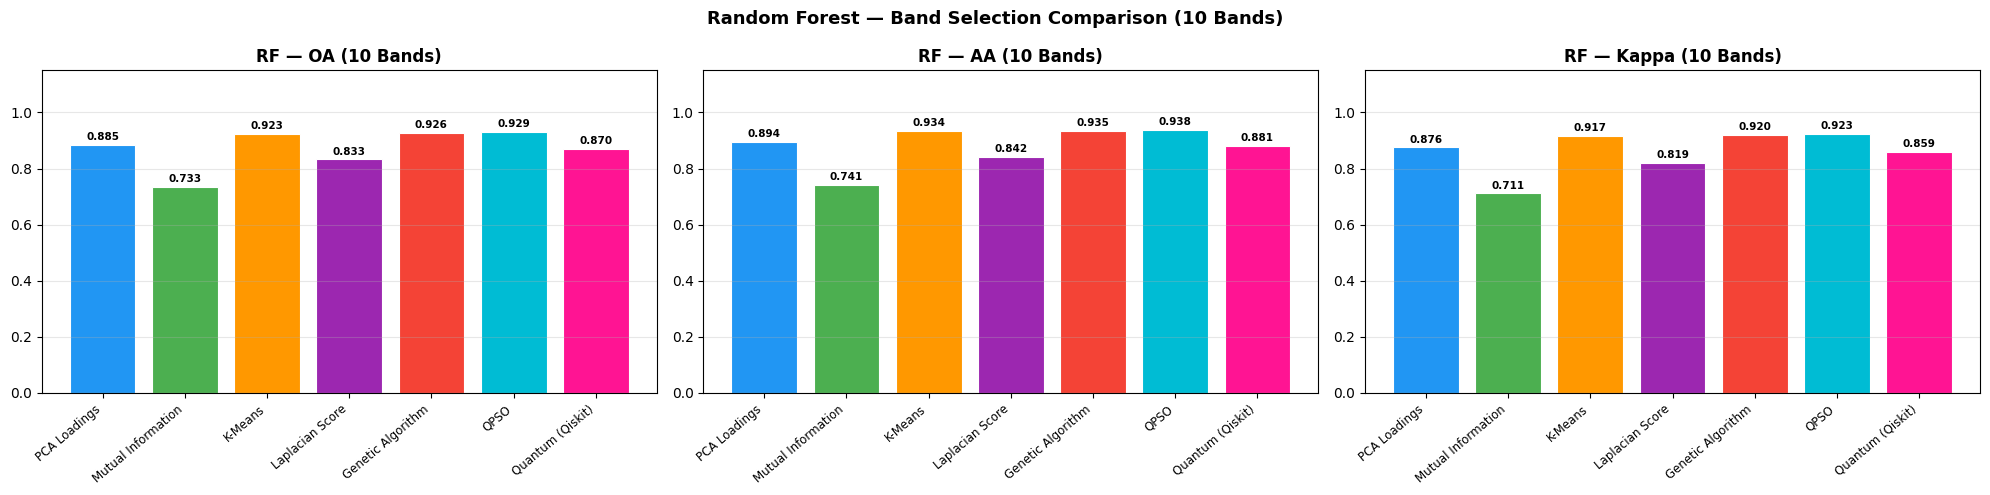

Saved: results/RF_comparison_10bands.png


In [19]:
# ============================================================
# Model 2 — Random Forest Classifier
# Separate results saved per band-selection method
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score

print("=" * 60)
print("MODEL 2 — RANDOM FOREST")
print("=" * 60)

rf_results = []

def evaluate_rf(X_tr, X_te, y_tr, y_te, method_label):
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    oa     = accuracy_score(y_te, y_pred)
    kappa  = cohen_kappa_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    aa     = np.mean([report[str(c)]['recall']
                      for c in np.unique(y_te) if str(c) in report])

    print(f"  [{method_label:28s}]  OA={oa:.4f}  AA={aa:.4f}  Kappa={kappa:.4f}")
    return {
        'Model'         : 'Random Forest',
        'Band_Selection': method_label,
        'N_Bands'       : N_BANDS,
        'OA'            : round(oa, 4),
        'AA'            : round(aa, 4),
        'Kappa'         : round(kappa, 4)
    }

# Run RF on all band selection methods
all_bands_dict = {
    'PCA Loadings'      : pca_bands,
    'Mutual Information': mi_bands,
    'K-Means'           : km_bands,
    'Laplacian Score'   : lap_bands,
    'Genetic Algorithm' : ga_bands,
    'QPSO'              : qpso_bands,
    'Quantum (Qiskit)'  : quantum_bands
}

for method_name, bands in all_bands_dict.items():
    res = evaluate_rf(
        X_train[:, bands], X_test[:, bands],
        y_train, y_test,
        method_name
    )
    rf_results.append(res)

# ── Save RF Separate CSV ──
os.makedirs('results', exist_ok=True)
df_rf = pd.DataFrame(rf_results)
df_rf.to_csv(f'results/RF_results_{N_BANDS}bands.csv', index=False)
print(f"\nSaved: results/RF_results_{N_BANDS}bands.csv")
print(df_rf.to_string(index=False))

# ── RF Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
metrics_list = ['OA', 'AA', 'Kappa']
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#FF1493']

for ax, metric in zip(axes, metrics_list):
    bars = ax.bar(df_rf['Band_Selection'], df_rf[metric],
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'RF — {metric} ({N_BANDS} Bands)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(df_rf['Band_Selection'], rotation=40, ha='right', fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_rf[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.suptitle(f'Random Forest — Band Selection Comparison ({N_BANDS} Bands)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'results/RF_comparison_{N_BANDS}bands.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: results/RF_comparison_{N_BANDS}bands.png")

MODEL 3 — XGBOOST
  [PCA Loadings                ]  OA=0.8913  AA=0.8985  Kappa=0.8822
  [Mutual Information          ]  OA=0.7292  AA=0.7350  Kappa=0.7067
  [K-Means                     ]  OA=0.9262  AA=0.9368  Kappa=0.9200
  [Laplacian Score             ]  OA=0.8390  AA=0.8494  Kappa=0.8256
  [Genetic Algorithm           ]  OA=0.9374  AA=0.9451  Kappa=0.9322
  [QPSO                        ]  OA=0.9313  AA=0.9371  Kappa=0.9256
  [Quantum (Qiskit)            ]  OA=0.8749  AA=0.8851  Kappa=0.8645

Saved: results/XGB_results_10bands.csv
  Model     Band_Selection  N_Bands     OA     AA  Kappa
XGBoost       PCA Loadings       10 0.8913 0.8985 0.8822
XGBoost Mutual Information       10 0.7292 0.7350 0.7067
XGBoost            K-Means       10 0.9262 0.9368 0.9200
XGBoost    Laplacian Score       10 0.8390 0.8494 0.8256
XGBoost  Genetic Algorithm       10 0.9374 0.9451 0.9322
XGBoost               QPSO       10 0.9313 0.9371 0.9256
XGBoost   Quantum (Qiskit)       10 0.8749 0.8851 0.8645


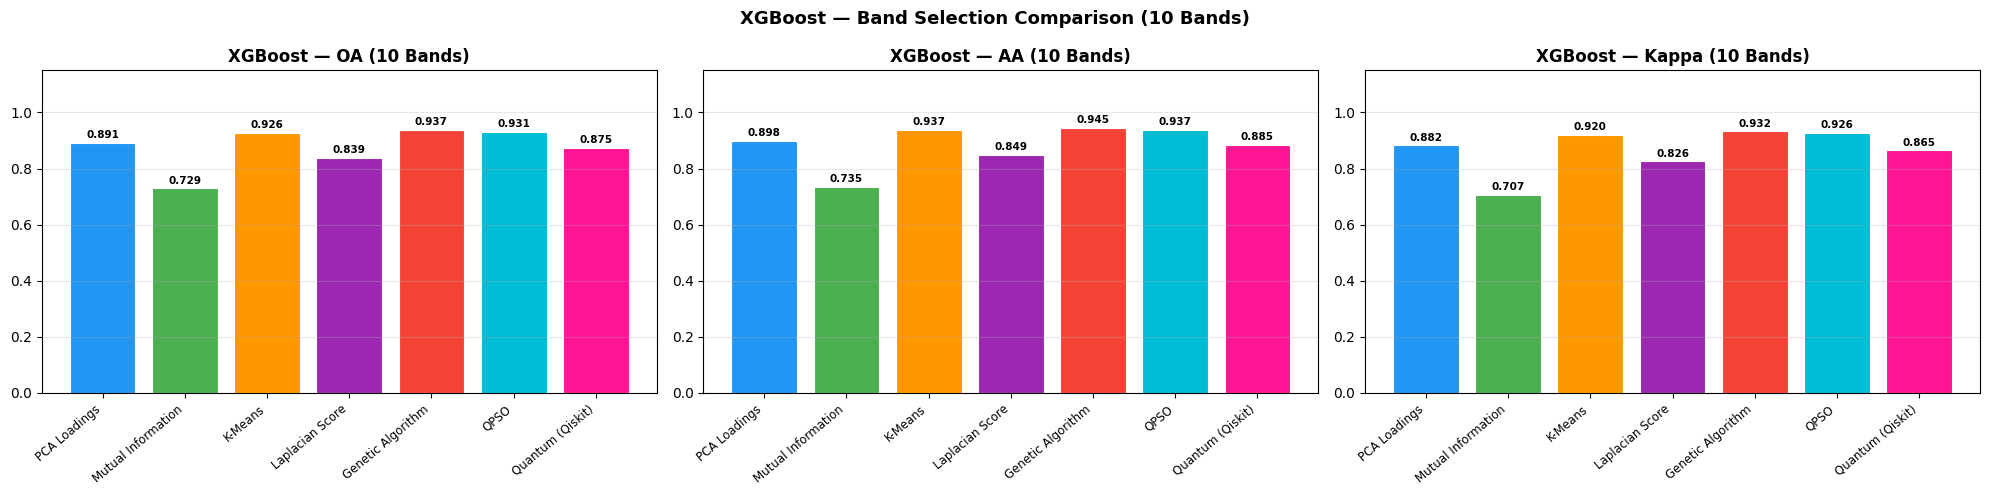

Saved: results/XGB_comparison_10bands.png


In [20]:
# ============================================================
# Model 3 — XGBoost Classifier
# Separate results saved per band-selection method
# ============================================================
!pip install xgboost -q
from xgboost import XGBClassifier

print("=" * 60)
print("MODEL 3 — XGBOOST")
print("=" * 60)

xgb_results = []

def evaluate_xgb(X_tr, X_te, y_tr, y_te, method_label):
    # XGBoost needs labels starting from 0
    y_tr_xgb = y_tr - y_tr.min()
    y_te_xgb = y_te - y_te.min()

    clf = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    clf.fit(X_tr, y_tr_xgb)
    y_pred = clf.predict(X_te)

    oa     = accuracy_score(y_te_xgb, y_pred)
    kappa  = cohen_kappa_score(y_te_xgb, y_pred)
    report = classification_report(y_te_xgb, y_pred, output_dict=True, zero_division=0)
    aa     = np.mean([report[str(c)]['recall']
                      for c in np.unique(y_te_xgb) if str(c) in report])

    print(f"  [{method_label:28s}]  OA={oa:.4f}  AA={aa:.4f}  Kappa={kappa:.4f}")
    return {
        'Model'         : 'XGBoost',
        'Band_Selection': method_label,
        'N_Bands'       : N_BANDS,
        'OA'            : round(oa, 4),
        'AA'            : round(aa, 4),
        'Kappa'         : round(kappa, 4)
    }

all_bands_dict = {
    'PCA Loadings'      : pca_bands,
    'Mutual Information': mi_bands,
    'K-Means'           : km_bands,
    'Laplacian Score'   : lap_bands,
    'Genetic Algorithm' : ga_bands,
    'QPSO'              : qpso_bands,
    'Quantum (Qiskit)'  : quantum_bands
}

for method_name, bands in all_bands_dict.items():
    res = evaluate_xgb(
        X_train[:, bands], X_test[:, bands],
        y_train, y_test,
        method_name
    )
    xgb_results.append(res)

# ── Save XGB Separate CSV ──
df_xgb = pd.DataFrame(xgb_results)
df_xgb.to_csv(f'results/XGB_results_{N_BANDS}bands.csv', index=False)
print(f"\nSaved: results/XGB_results_{N_BANDS}bands.csv")
print(df_xgb.to_string(index=False))

# ── XGB Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric in zip(axes, metrics_list):
    bars = ax.bar(df_xgb['Band_Selection'], df_xgb[metric],
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'XGBoost — {metric} ({N_BANDS} Bands)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(df_xgb['Band_Selection'], rotation=40, ha='right', fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_xgb[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.suptitle(f'XGBoost — Band Selection Comparison ({N_BANDS} Bands)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'results/XGB_comparison_{N_BANDS}bands.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: results/XGB_comparison_{N_BANDS}bands.png")

MODEL 4 — LIGHTGBM
  [PCA Loadings                ]  OA=0.8903  AA=0.8985  Kappa=0.8811
  [Mutual Information          ]  OA=0.7159  AA=0.7279  Kappa=0.6923
  [K-Means                     ]  OA=0.9262  AA=0.9369  Kappa=0.9200
  [Laplacian Score             ]  OA=0.8154  AA=0.8299  Kappa=0.8000
  [Genetic Algorithm           ]  OA=0.9385  AA=0.9456  Kappa=0.9333
  [QPSO                        ]  OA=0.9344  AA=0.9398  Kappa=0.9289
  [Quantum (Qiskit)            ]  OA=0.8728  AA=0.8812  Kappa=0.8623

Saved: results/LGBM_results_10bands.csv
   Model     Band_Selection  N_Bands     OA     AA  Kappa
LightGBM       PCA Loadings       10 0.8903 0.8985 0.8811
LightGBM Mutual Information       10 0.7159 0.7279 0.6923
LightGBM            K-Means       10 0.9262 0.9369 0.9200
LightGBM    Laplacian Score       10 0.8154 0.8299 0.8000
LightGBM  Genetic Algorithm       10 0.9385 0.9456 0.9333
LightGBM               QPSO       10 0.9344 0.9398 0.9289
LightGBM   Quantum (Qiskit)       10 0.8728 0.8812 

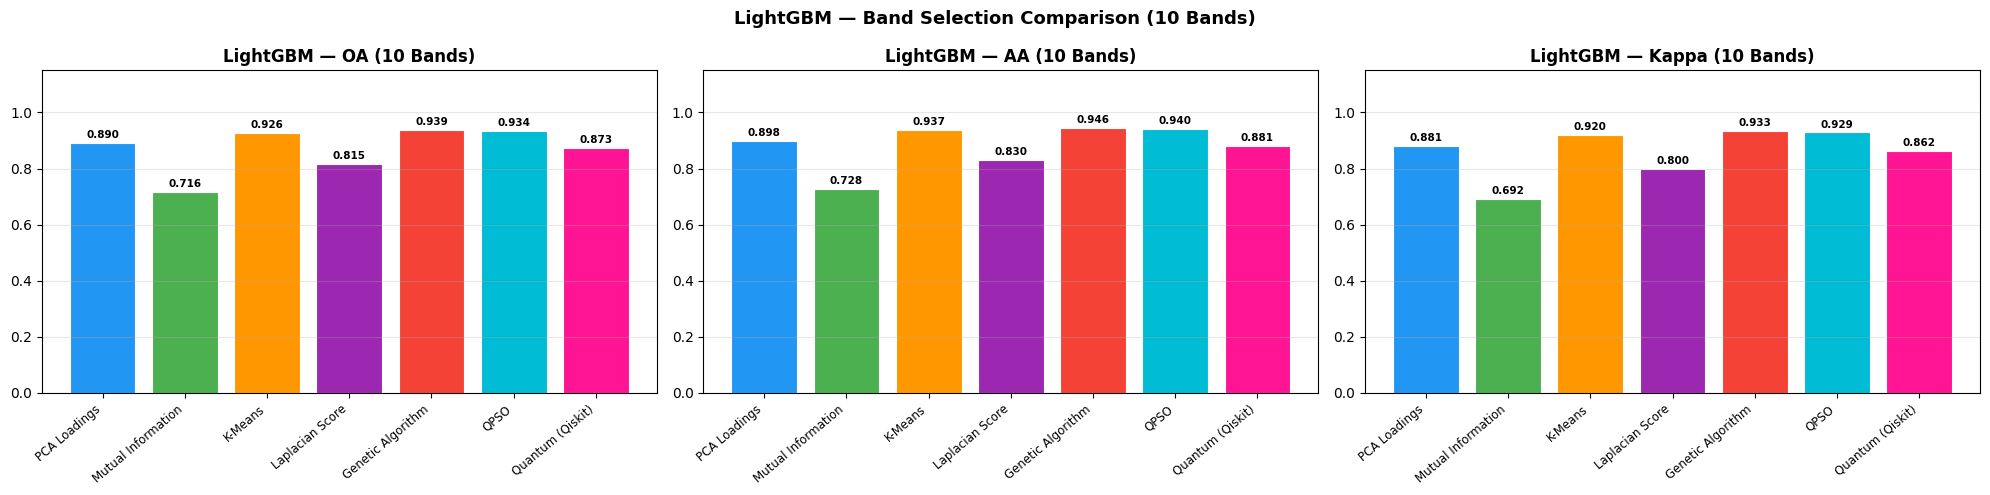

Saved: results/LGBM_comparison_10bands.png


In [21]:
# ============================================================
# Model 4 — LightGBM Classifier
# Separate results saved per band-selection method
# ============================================================
!pip install lightgbm -q
from lightgbm import LGBMClassifier

print("=" * 60)
print("MODEL 4 — LIGHTGBM")
print("=" * 60)

lgbm_results = []

def evaluate_lgbm(X_tr, X_te, y_tr, y_te, method_label):
    clf = LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    oa     = accuracy_score(y_te, y_pred)
    kappa  = cohen_kappa_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    aa     = np.mean([report[str(c)]['recall']
                      for c in np.unique(y_te) if str(c) in report])

    print(f"  [{method_label:28s}]  OA={oa:.4f}  AA={aa:.4f}  Kappa={kappa:.4f}")
    return {
        'Model'         : 'LightGBM',
        'Band_Selection': method_label,
        'N_Bands'       : N_BANDS,
        'OA'            : round(oa, 4),
        'AA'            : round(aa, 4),
        'Kappa'         : round(kappa, 4)
    }

all_bands_dict = {
    'PCA Loadings'      : pca_bands,
    'Mutual Information': mi_bands,
    'K-Means'           : km_bands,
    'Laplacian Score'   : lap_bands,
    'Genetic Algorithm' : ga_bands,
    'QPSO'              : qpso_bands,
    'Quantum (Qiskit)'  : quantum_bands
}

for method_name, bands in all_bands_dict.items():
    res = evaluate_lgbm(
        X_train[:, bands], X_test[:, bands],
        y_train, y_test,
        method_name
    )
    lgbm_results.append(res)

# ── Save LGBM Separate CSV ──
df_lgbm = pd.DataFrame(lgbm_results)
df_lgbm.to_csv(f'results/LGBM_results_{N_BANDS}bands.csv', index=False)
print(f"\nSaved: results/LGBM_results_{N_BANDS}bands.csv")
print(df_lgbm.to_string(index=False))

# ── LGBM Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric in zip(axes, metrics_list):
    bars = ax.bar(df_lgbm['Band_Selection'], df_lgbm[metric],
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'LightGBM — {metric} ({N_BANDS} Bands)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(df_lgbm['Band_Selection'], rotation=40, ha='right', fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_lgbm[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.suptitle(f'LightGBM — Band Selection Comparison ({N_BANDS} Bands)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'results/LGBM_comparison_{N_BANDS}bands.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: results/LGBM_comparison_{N_BANDS}bands.png")

MODEL 5 — K-NEAREST NEIGHBORS (KNN)
  [PCA Loadings                ]  OA=0.8574  AA=0.8620  Kappa=0.8455
  [Mutual Information          ]  OA=0.7169  AA=0.7310  Kappa=0.6935
  [K-Means                     ]  OA=0.9138  AA=0.9266  Kappa=0.9067
  [Laplacian Score             ]  OA=0.8246  AA=0.8373  Kappa=0.8101
  [Genetic Algorithm           ]  OA=0.9323  AA=0.9412  Kappa=0.9267
  [QPSO                        ]  OA=0.9456  AA=0.9522  Kappa=0.9411
  [Quantum (Qiskit)            ]  OA=0.8544  AA=0.8670  Kappa=0.8423

Saved: results/KNN_results_10bands.csv
Model     Band_Selection  N_Bands     OA     AA  Kappa
  KNN       PCA Loadings       10 0.8574 0.8620 0.8455
  KNN Mutual Information       10 0.7169 0.7310 0.6935
  KNN            K-Means       10 0.9138 0.9266 0.9067
  KNN    Laplacian Score       10 0.8246 0.8373 0.8101
  KNN  Genetic Algorithm       10 0.9323 0.9412 0.9267
  KNN               QPSO       10 0.9456 0.9522 0.9411
  KNN   Quantum (Qiskit)       10 0.8544 0.8670 0.8423


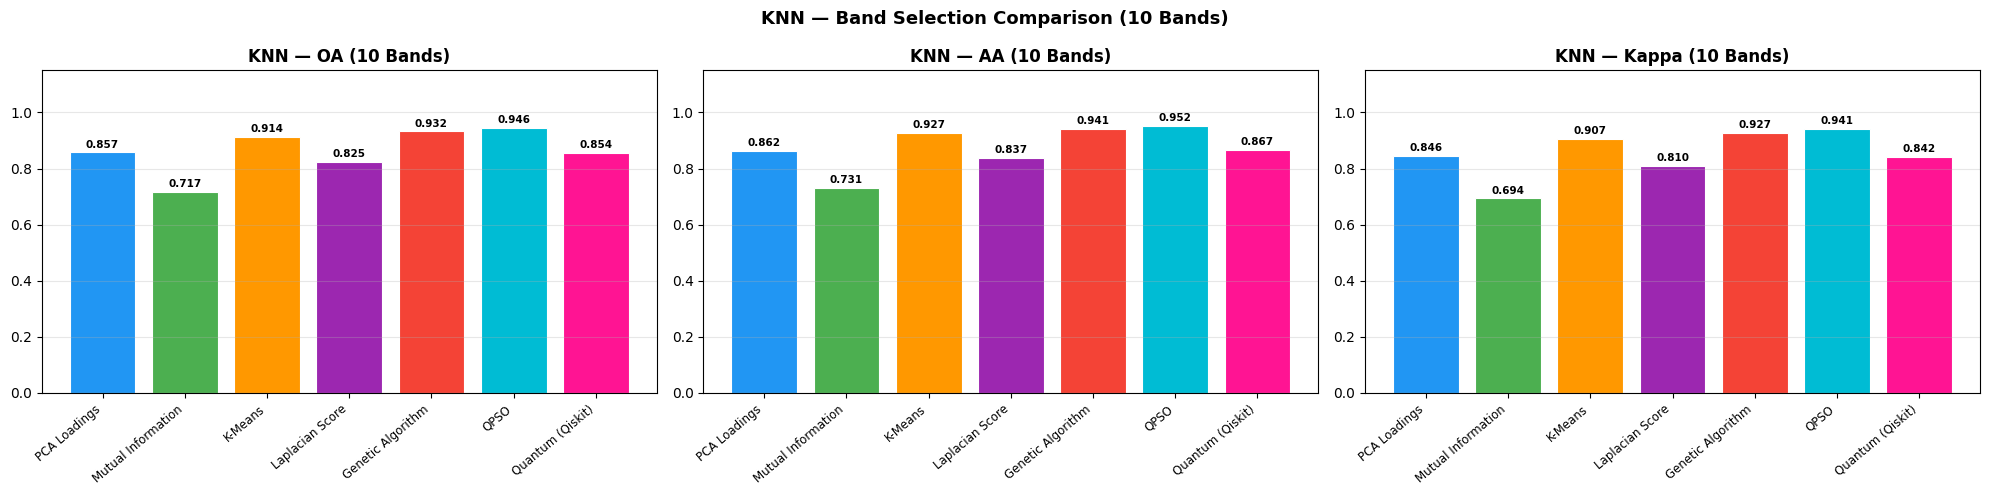

Saved: results/KNN_comparison_10bands.png


In [22]:
# ============================================================
# Model 5 — K-Nearest Neighbors (KNN)
# Separate results saved per band-selection method
# ============================================================
from sklearn.neighbors import KNeighborsClassifier

print("=" * 60)
print("MODEL 5 — K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

knn_results = []

def evaluate_knn(X_tr, X_te, y_tr, y_te, method_label):
    clf = KNeighborsClassifier(
        n_neighbors=5,
        metric='euclidean',
        weights='distance',   # closer neighbors have more influence
        n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    oa     = accuracy_score(y_te, y_pred)
    kappa  = cohen_kappa_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    aa     = np.mean([report[str(c)]['recall']
                      for c in np.unique(y_te) if str(c) in report])

    print(f"  [{method_label:28s}]  OA={oa:.4f}  AA={aa:.4f}  Kappa={kappa:.4f}")
    return {
        'Model'         : 'KNN',
        'Band_Selection': method_label,
        'N_Bands'       : N_BANDS,
        'OA'            : round(oa, 4),
        'AA'            : round(aa, 4),
        'Kappa'         : round(kappa, 4)
    }

all_bands_dict = {
    'PCA Loadings'      : pca_bands,
    'Mutual Information': mi_bands,
    'K-Means'           : km_bands,
    'Laplacian Score'   : lap_bands,
    'Genetic Algorithm' : ga_bands,
    'QPSO'              : qpso_bands,
    'Quantum (Qiskit)'  : quantum_bands
}

for method_name, bands in all_bands_dict.items():
    res = evaluate_knn(
        X_train[:, bands], X_test[:, bands],
        y_train, y_test,
        method_name
    )
    knn_results.append(res)

# ── Save KNN Separate CSV ──
df_knn = pd.DataFrame(knn_results)
df_knn.to_csv(f'results/KNN_results_{N_BANDS}bands.csv', index=False)
print(f"\nSaved: results/KNN_results_{N_BANDS}bands.csv")
print(df_knn.to_string(index=False))

# ── KNN Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric in zip(axes, metrics_list):
    bars = ax.bar(df_knn['Band_Selection'], df_knn[metric],
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'KNN — {metric} ({N_BANDS} Bands)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(df_knn['Band_Selection'], rotation=40, ha='right', fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_knn[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.suptitle(f'KNN — Band Selection Comparison ({N_BANDS} Bands)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'results/KNN_comparison_{N_BANDS}bands.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: results/KNN_comparison_{N_BANDS}bands.png")

COMBINED RESULTS — ALL MODELS
Saved: results/ALL_MODELS_results_10bands.csv
        Model             Band_Selection  N_Bands     OA     AA  Kappa
          SVM               PCA Loadings       10 0.9005 0.9060 0.8922
          SVM         Mutual Information       10 0.7610 0.7700 0.7413
          SVM         K-Means Clustering       10 0.9477 0.9545 0.9433
          SVM            Laplacian Score       10 0.8615 0.8723 0.8501
          SVM          Genetic Algorithm       10 0.9651 0.9689 0.9622
          SVM                       QPSO       10 0.9703 0.9739 0.9678
          SVM Quantum Amplitude (Qiskit)       10 0.8944 0.9079 0.8856
Random Forest               PCA Loadings       10 0.8851 0.8945 0.8756
Random Forest         Mutual Information       10 0.7333 0.7414 0.7113
Random Forest                    K-Means       10 0.9231 0.9337 0.9167
Random Forest            Laplacian Score       10 0.8328 0.8418 0.8189
Random Forest          Genetic Algorithm       10 0.9262 0.9355 0.9200
R

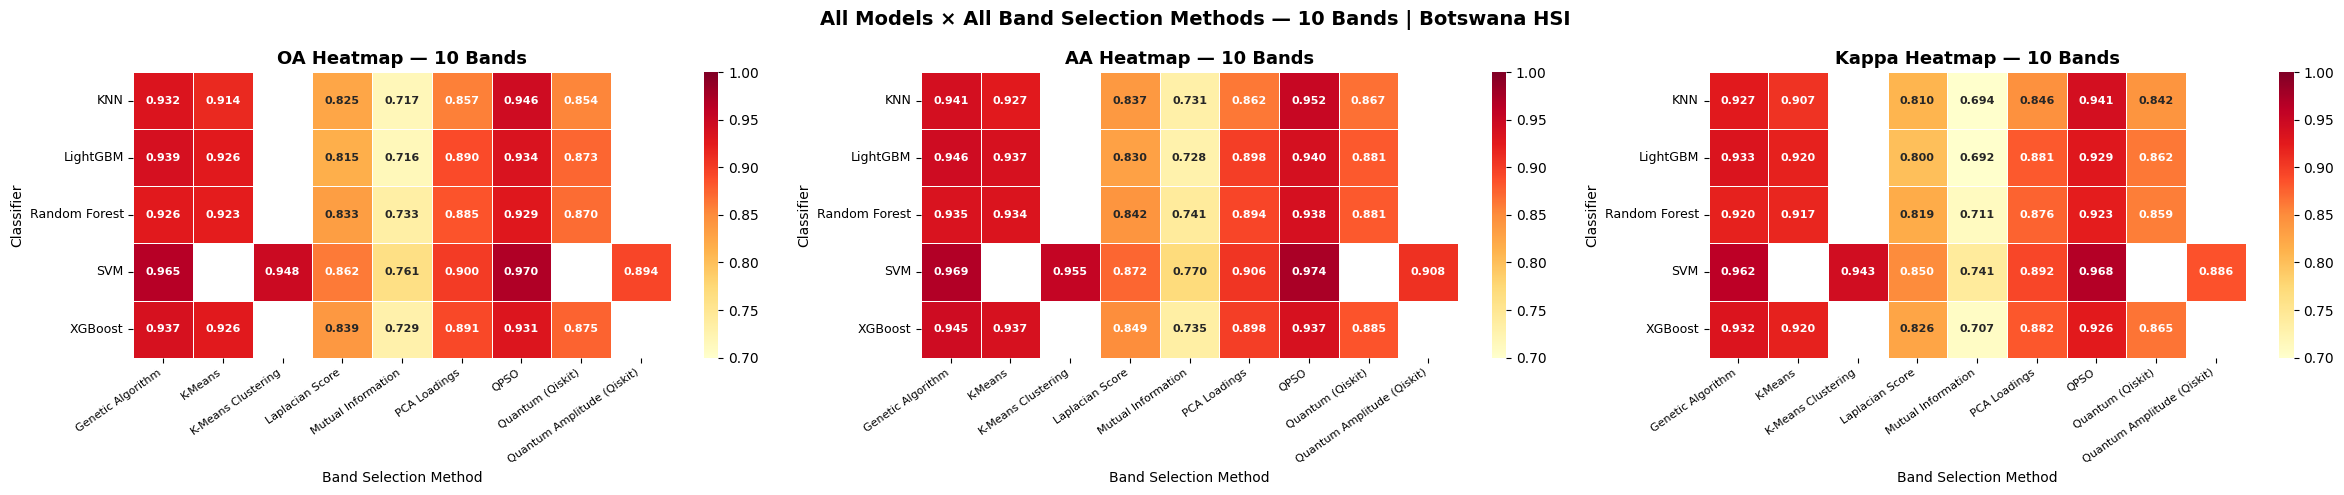

Saved: results/COMBINED_heatmap_10bands.png

===== BEST COMBINATIONS =====
Best OA    : SVM             + QPSO                 → OA=0.9703
Best Kappa : SVM             + QPSO                 → Kappa=0.9678


In [23]:
# ============================================================
# FINAL — Combined Results: All 5 Models × All 7 Band Methods
# ============================================================
print("=" * 60)
print("COMBINED RESULTS — ALL MODELS")
print("=" * 60)

# Get SVM results from your existing results list
df_svm = pd.DataFrame(results)
df_svm.insert(0, 'Model', 'SVM')
df_svm = df_svm.rename(columns={'Method': 'Band_Selection'})
df_svm = df_svm[['Model', 'Band_Selection', 'N_Bands', 'OA', 'AA', 'Kappa']]

# Combine all models
df_combined = pd.concat([
    df_svm,
    df_rf,
    df_xgb,
    df_lgbm,
    df_knn
], ignore_index=True)

# ── Save Combined CSV ──
df_combined.to_csv(f'results/ALL_MODELS_results_{N_BANDS}bands.csv', index=False)
print(f"Saved: results/ALL_MODELS_results_{N_BANDS}bands.csv")
print(df_combined.to_string(index=False))

# ── Combined Heatmap — OA per Model × Band Method ──
pivot_oa = df_combined.pivot(index='Model', columns='Band_Selection', values='OA')

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
pivot_tables = {
    'OA'   : df_combined.pivot(index='Model', columns='Band_Selection', values='OA'),
    'AA'   : df_combined.pivot(index='Model', columns='Band_Selection', values='AA'),
    'Kappa': df_combined.pivot(index='Model', columns='Band_Selection', values='Kappa')
}

for ax, (metric, pivot) in zip(axes, pivot_tables.items()):
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd',
        vmin=0.7,
        vmax=1.0,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8, 'weight': 'bold'}
    )
    ax.set_title(f'{metric} Heatmap — {N_BANDS} Bands',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Band Selection Method', fontsize=10)
    ax.set_ylabel('Classifier', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle(
    f'All Models × All Band Selection Methods — {N_BANDS} Bands | Botswana HSI',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'results/COMBINED_heatmap_{N_BANDS}bands.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: results/COMBINED_heatmap_{N_BANDS}bands.png")

# ── Best Combination Summary ──
print("\n===== BEST COMBINATIONS =====")
best_oa    = df_combined.loc[df_combined['OA'].idxmax()]
best_kappa = df_combined.loc[df_combined['Kappa'].idxmax()]
print(f"Best OA    : {best_oa['Model']:15s} + {best_oa['Band_Selection']:20s} → OA={best_oa['OA']:.4f}")
print(f"Best Kappa : {best_kappa['Model']:15s} + {best_kappa['Band_Selection']:20s} → Kappa={best_kappa['Kappa']:.4f}")